## Part 1: Environment Setup & Validation
### 1.1 Installation
Install required computer vision and visualization libraries using Jupyter magic commands.


In [1]:
%pip install opencv-python matplotlib pandas numpy


### 1.2 Import & Validate
Import `cv2` and `matplotlib.pyplot as plt`. Validate the environment before proceeding.


In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Quick environment validation
print(f"OpenCV Version: {cv2.__version__}")
print(f"NumPy Version : {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
print("Validation successful: All libraries loaded properly.")


OpenCV Version: 4.13.0
NumPy Version : 2.3.5
Pandas Version: 2.3.3
Validation successful: All libraries loaded properly.


## Part 2: Python Data Structures & Logic
### Task 1: Object-Oriented Grocery Manager
Create a `GroceryManager` class with methods `add_item(item, quantity, price)`, `remove_item(item)`, `view_list()`, and `calculate_total()` with basic error handling.


In [3]:
class GroceryManager:
    def __init__(self):
        self.cart = {}

    def add_item(self, item, quantity, price):
        self.cart[item] = {"qty": quantity, "price": price}

    def remove_item(self, item):
        if item in self.cart:
            del self.cart[item]
        else:
            print(f"Error: '{item}' not found in grocery list.")

    def view_list(self):
        for item, data in self.cart.items():
            print(f"{item}: {data['qty']} pcs @ ${data['price']:.2f}")

    def calculate_total(self):
        return sum(d["qty"] * d["price"] for d in self.cart.values())

# Demonstration
gm = GroceryManager()
gm.add_item("Apple", 5, 1.20)
gm.add_item("Milk", 2, 2.50)
gm.add_item("Bread", 1, 1.80)

print("--- Current Grocery List ---")
gm.view_list()
print(f"Total Cost: ${gm.calculate_total():.2f}\n")

# Error check for non-existent item
gm.remove_item("Eggs")
gm.remove_item("Bread")

print("\n--- After Removal ---")
gm.view_list()
print(f"Updated Total: ${gm.calculate_total():.2f}")


--- Current Grocery List ---
Apple: 5 pcs @ $1.20
Milk: 2 pcs @ $2.50
Bread: 1 pcs @ $1.80
Total Cost: $12.80

Error: 'Eggs' not found in grocery list.

--- After Removal ---
Apple: 5 pcs @ $1.20
Milk: 2 pcs @ $2.50
Updated Total: $11.00


### Task 2: Advanced Student Record System
Build a nested dictionary-based student record system with functions to find the highest average grade and filter by major.


In [4]:
students = {
    101: {"Name": "Ali", "Major": "AI", "Grades": [85, 92, 88]},
    102: {"Name": "Sara", "Major": "CS", "Grades": [95, 91, 97]},
    103: {"Name": "Zain", "Major": "AI", "Grades": [78, 85, 80]},
    104: {"Name": "Hina", "Major": "SE", "Grades": [89, 94, 90]}
}

def top_student(records):
    avg = lambda g: sum(g) / len(g)
    best = max(records.values(), key=lambda s: avg(s["Grades"]))
    return best["Name"]

def search_by_major(records, major):
    print(f"Students enrolled in {major}:")
    for s in records.values():
        if s["Major"].lower() == major.lower():
            print(f"- {s['Name']}")

# Demonstration
print(f"Top Student: {top_student(students)}\n")
search_by_major(students, "AI")


Top Student: Sara

Students enrolled in AI:
- Ali
- Zain


## Part 3: Core Computer Vision & Matplotlib
*All image visualization tasks utilize Matplotlib subplots for side-by-side comparisons unless stated otherwise.*

### Task 3: Safe Image Loading & RGB Visualization
Load `Sukuna.jpeg`, check for safe load, convert BGR to RGB, and display with formatted title.


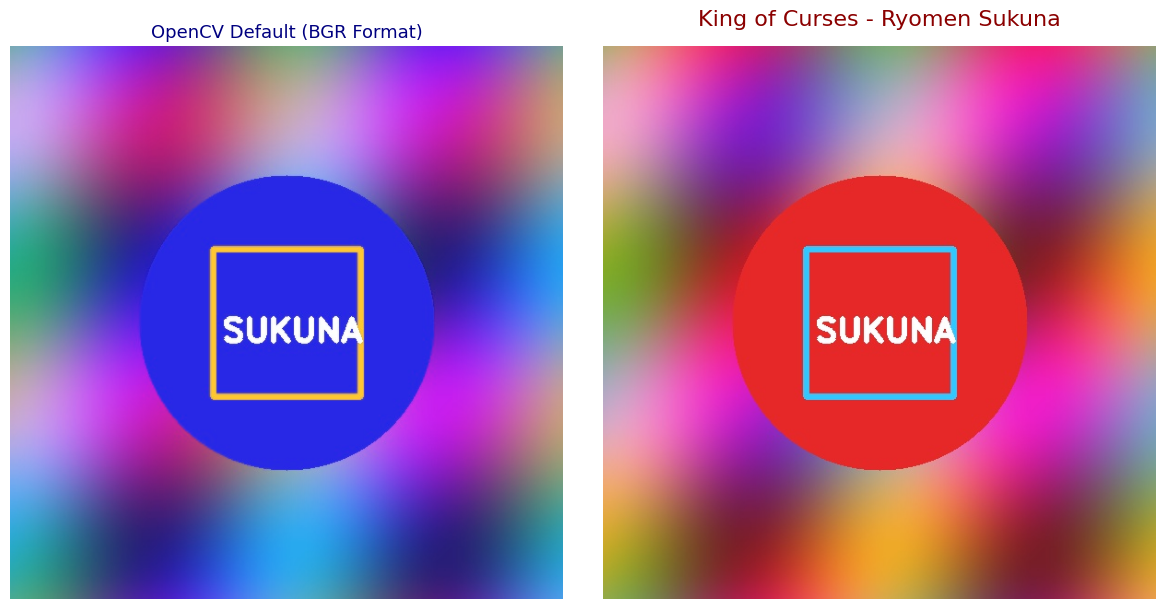

In [5]:
image_path = "Sukuna.jpeg"
image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found.")
else:
    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Subplot side-by-side comparison: BGR vs RGB
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].imshow(image)
    ax[0].set_title("OpenCV Default (BGR Format)", fontsize=13, color="navy")
    ax[0].axis("off")

    ax[1].imshow(img_rgb)
    ax[1].set_title("King of Curses - Ryomen Sukuna", fontsize=16, color="darkred", pad=15)
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()


### Task 4: Interactive Geometry & Blank Canvas
Create an 800x800 blank black image using NumPy, draw 5 concentric circles with alternating colors, add a bounding box around the outermost circle, and print exact center coordinates.


Exact Center Coordinates: (400, 400)


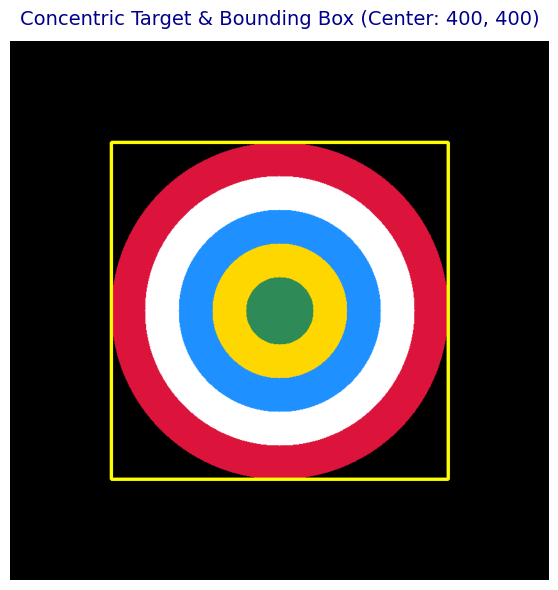

In [6]:
canvas = np.zeros((800, 800, 3), dtype=np.uint8)
cx, cy = 800 // 2, 800 // 2
print(f"Exact Center Coordinates: ({cx}, {cy})")

# 5 concentric circles with alternating colors
radii = [250, 200, 150, 100, 50]
colors = [
    (220, 20, 60),    # Crimson
    (255, 255, 255),  # White
    (30, 144, 255),   # Dodger Blue
    (255, 215, 0),    # Gold
    (46, 139, 87)     # Sea Green
]

for r, col in zip(radii, colors):
    cv2.circle(canvas, (cx, cy), r, col, -1)

# Bounding box around outermost circle (radius = 250)
r_max = radii[0]
cv2.rectangle(canvas, (cx - r_max, cy - r_max), (cx + r_max, cy + r_max), (255, 255, 0), 3)

plt.figure(figsize=(7, 7))
plt.imshow(canvas)
plt.title(f"Concentric Target & Bounding Box (Center: {cx}, {cy})", fontsize=14, color="darkblue", pad=12)
plt.axis("off")
plt.show()


### Task 5: Advanced Blurring & NumPy ROI Extraction
Apply a 25x25 Gaussian blur and extract a 300x300 pixel Region of Interest (ROI) from the exact center of both the original and blurred images.


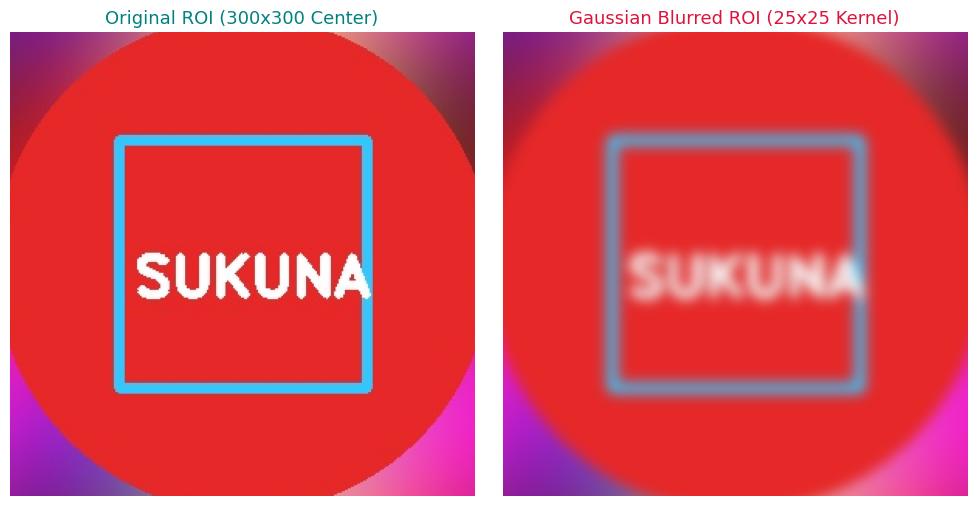

In [7]:
# Apply heavy Gaussian Blur (25x25 kernel)
blurred = cv2.GaussianBlur(img_rgb, (25, 25), 0)

h, w, _ = img_rgb.shape
cy, cx = h // 2, w // 2

# 300x300 center ROI using NumPy slicing
roi_orig = img_rgb[cy - 150 : cy + 150, cx - 150 : cx + 150]
roi_blur = blurred[cy - 150 : cy + 150, cx - 150 : cx + 150]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(roi_orig)
ax[0].set_title("Original ROI (300x300 Center)", fontsize=13, color="teal")
ax[0].axis("off")

ax[1].imshow(roi_blur)
ax[1].set_title("Gaussian Blurred ROI (25x25 Kernel)", fontsize=13, color="crimson")
ax[1].axis("off")

plt.tight_layout()
plt.show()


### Task 6: Alpha Blending & Typography
Create a solid color overlay covering the bottom 20% of the image, blend using `cv2.addWeighted()`, and add typography title using `cv2.putText()`.


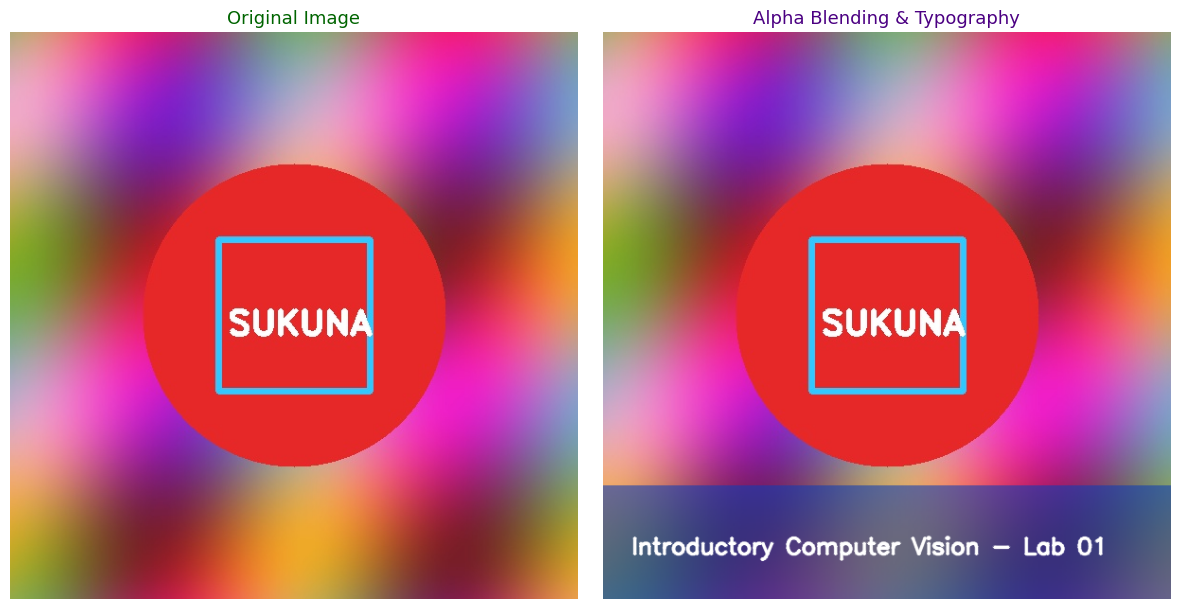

In [8]:
h, w, _ = img_rgb.shape
overlay = img_rgb.copy()
y_start = int(h * 0.8)

# Blue rectangular overlay on bottom 20%
overlay[y_start:h, :] = [15, 60, 180]

# Semi-transparent blending (60% overlay, 40% original)
alpha = 0.6
blended = cv2.addWeighted(overlay, alpha, img_rgb, 1 - alpha, 0)

# Add title typography over transparent box
text = "Introductory Computer Vision - Lab 01"
cv2.putText(blended, text, (30, y_start + int(h * 0.12)), 
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(img_rgb)
ax[0].set_title("Original Image", fontsize=13, color="darkgreen")
ax[0].axis("off")

ax[1].imshow(blended)
ax[1].set_title("Alpha Blending & Typography", fontsize=13, color="indigo")
ax[1].axis("off")

plt.tight_layout()
plt.show()


### Task 7: Matrix-Based Rotation & Adaptive Thresholding
Compare Global Binary Thresholding vs Adaptive Thresholding on a high-contrast image, then rotate the adaptive threshold output by 45° with 0.8 scaling using `cv2.getRotationMatrix2D()`.


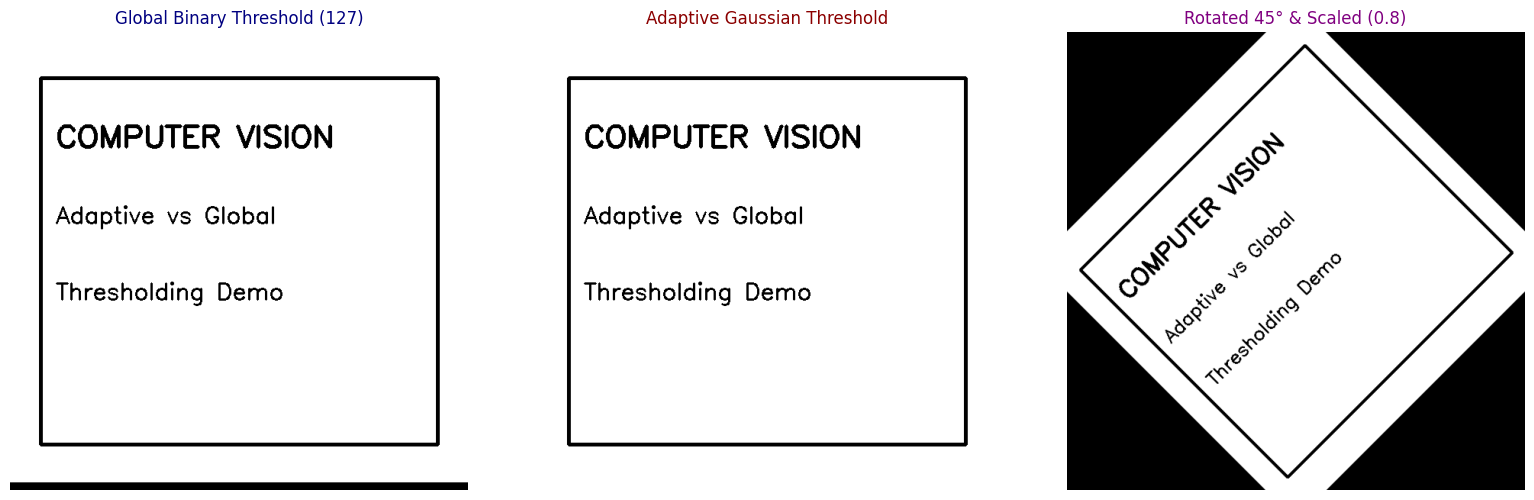

In [9]:
doc_bgr = cv2.imread("document.png")
gray = cv2.cvtColor(doc_bgr, cv2.COLOR_BGR2GRAY)

# Global vs Adaptive Thresholding
_, bin_thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
adp_thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                 cv2.THRESH_BINARY, 11, 2)

# Matrix-based 45-degree rotation scaled by 0.8
gh, gw = gray.shape
M = cv2.getRotationMatrix2D((gw / 2, gh / 2), 45, 0.8)
rotated = cv2.warpAffine(adp_thresh, M, (gw, gh))

fig, ax = plt.subplots(1, 3, figsize=(16, 5))

ax[0].imshow(bin_thresh, cmap="gray")
ax[0].set_title("Global Binary Threshold (127)", fontsize=12, color="navy")
ax[0].axis("off")

ax[1].imshow(adp_thresh, cmap="gray")
ax[1].set_title("Adaptive Gaussian Threshold", fontsize=12, color="darkred")
ax[1].axis("off")

ax[2].imshow(rotated, cmap="gray")
ax[2].set_title("Rotated 45° & Scaled (0.8)", fontsize=12, color="purple")
ax[2].axis("off")

plt.tight_layout()
plt.show()


### Task 8: Masking with Bitwise Logic
Resize two images to 500x500, create a binary mask, and use `cv2.bitwise_and`, `cv2.bitwise_not`, and `cv2.bitwise_or` to combine them.


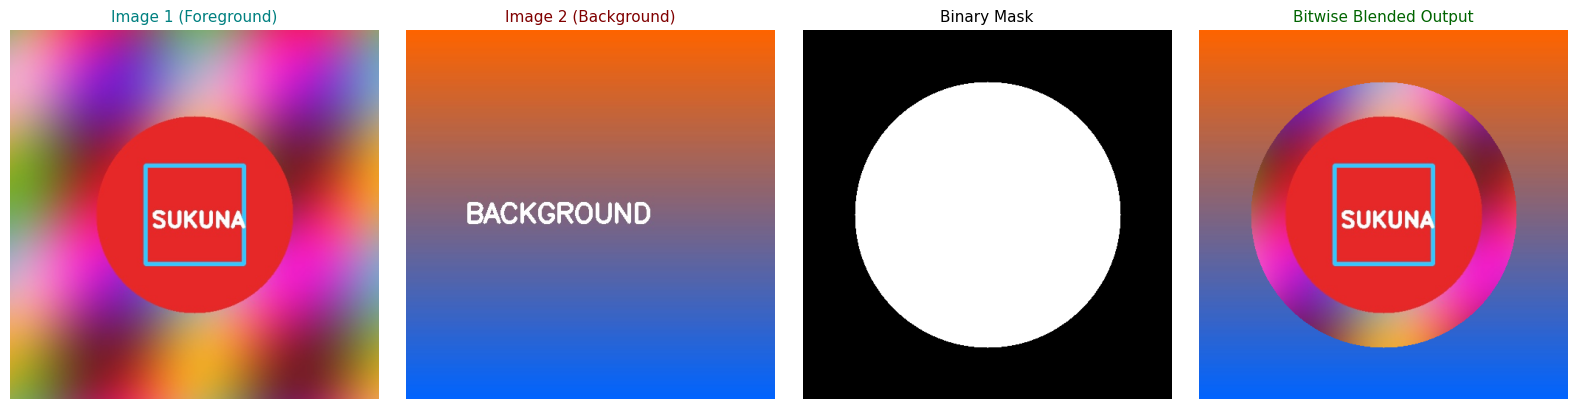

In [10]:
im1 = cv2.resize(img_rgb, (500, 500))
im2 = cv2.resize(cv2.cvtColor(cv2.imread("sample2.jpeg"), cv2.COLOR_BGR2RGB), (500, 500))

# Circular binary mask
mask = np.zeros((500, 500), dtype=np.uint8)
cv2.circle(mask, (250, 250), 180, 255, -1)
mask_inv = cv2.bitwise_not(mask)

# Bitwise cutouts & fusion
fore = cv2.bitwise_and(im1, im1, mask=mask)
back = cv2.bitwise_and(im2, im2, mask=mask_inv)
combo = cv2.bitwise_or(fore, back)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))

ax[0].imshow(im1)
ax[0].set_title("Image 1 (Foreground)", fontsize=11, color="teal")
ax[0].axis("off")

ax[1].imshow(im2)
ax[1].set_title("Image 2 (Background)", fontsize=11, color="maroon")
ax[1].axis("off")

ax[2].imshow(mask, cmap="gray")
ax[2].set_title("Binary Mask", fontsize=11, color="black")
ax[2].axis("off")

ax[3].imshow(combo)
ax[3].set_title("Bitwise Blended Output", fontsize=11, color="darkgreen")
ax[3].axis("off")

plt.tight_layout()
plt.show()


### Task 9: Statistical Image Profiling with Pandas
Flatten Red, Green, and Blue channels into 1D arrays, load into a Pandas DataFrame, and calculate summary statistics using `.describe()`.


In [11]:
r = img_rgb[:, :, 0].flatten()
g = img_rgb[:, :, 1].flatten()
b = img_rgb[:, :, 2].flatten()

# Load into Pandas DataFrame
df = pd.DataFrame({"Red": r, "Green": g, "Blue": b})

# Compute statistics with .describe()
stats = df.describe().loc[["mean", "min", "max", "std"]]

print("Color Channel Statistical Profile (Pandas):")
print("-" * 45)
print(stats)


Color Channel Statistical Profile (Pandas):
---------------------------------------------
             Red       Green        Blue
mean  187.579708   84.014056  107.694369
min    42.000000   20.000000   25.000000
max   255.000000  255.000000  255.000000
std    44.948182   50.431789   62.948888
